In [1]:
import os
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from lib import census as lc
from lib import io as lio

In [2]:
year = 2018

In [3]:
pums = pd.read_parquet("../data/pums/pums_100_2018.parquet")
pums

,REF_INDEX,SEC_INDEX,NUM_CHILDREN_UNDER_6,NUM_CHILDREN_6_TO_17,SIZE,NUM_IN_IF,NUM_WORKING,RENTGRS,HHINCOME,PERWT,...,AAPI_REF,OTHER_RACE_REF,RACE_ETHNICITY_REF,LATINO_SEC,WHITE_SEC,BLACK_SEC,INDIAN_SEC,AAPI_SEC,OTHER_RACE_SEC,RACE_ETHNICITY_SEC
UNIT,,,,,,,,,,,,,,,,,,,,,
2018000277858_P,2018000277858001,2018000277858002,0,0,2,0,0,0,123800,46.0,...,0,0,1,0,1,0,0,0,0,1
2018001331204_I2,2018001331204002,2018001331204002,0,0,1,1,1,800,500,215.0,...,0,0,99,1,0,0,0,0,0,99
2018001188817_P,2018001188817001,2018001188817002,0,0,2,2,2,0,89000,59.0,...,0,0,1,0,1,0,0,0,0,1
2018001182700_P,2018001182700001,2018001182700001,0,0,1,1,1,0,29900,112.0,...,0,0,1,0,1,0,0,0,0,1
2018000271732_I3,2018000271732003,2018000271732003,0,0,1,1,1,0,111500,125.0,...,0,0,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018000947916_P,2018000947916001,2018000947916001,0,0,1,1,1,1030,19200,67.0,...,0,0,2,0,0,1,0,0,0,2
2018000950420_P,2018000950420001,2018000950420002,0,0,2,2,2,0,86600,88.0,...,1,0,4,0,0,0,0,1,0,4
2018010134587_I1,2018010134587001,2018010134587001,0,0,1,0,0,0,9999999,81.0,...,0,0,1,0,1,0,0,0,0,1


In [4]:
# per-geography (PUMA / MIGPUMA) tables: ACS + LODES + CBSA + weather + CBP establishment
# counts joined per area, with the numeric CBSA type/name encoding (factorized on the PUMA
# side so the two are comparable) and the derived per-capita / NAICS job-share columns.
# Same tables create_estdata.ipynb builds its .ORIG and per-alternative blocks from.
puma_data, migpuma_data = lc.load_geo_tables("../data", year)

# PUMA<->MIGPUMA equivalency table (already indexed by PUMA, State already zero-padded
# as it's read as dtype=str)
puma_migpuma = lio.load_puma_migpuma(
    "../data/geometry/equivalencies/puma_migpuma_2010.csv"
)
distance_matrix = lio.load_distance_matrix(
    "../data/distances/puma_migpuma_distance_matrix.csv", zfill=7
)

In [5]:
leavers = pums[pums["STAY"] == 0].copy()

In [6]:
leavers["dist"] = distance_matrix.values[
    distance_matrix.index.get_indexer(leavers["ORIGIN"]),
    distance_matrix.columns.get_indexer(leavers["CHOSEN"]),
]
leavers["logdist"] = np.log1p(leavers["dist"])

In [7]:
leavers["dist"]

UNIT
2018000149309_P      172281.0
2018000702474_I4      63674.0
2018000000447_I2    1421114.0
2018000482831_P     3111497.0
2018010116178_I1    2360543.0
                      ...    
2018000642737_I3      73654.0
2018010141883_I1    2000101.0
2018010133390_I1     213605.0
2018010105012_I1     272525.0
2018001083840_I2      68472.0
Name: dist, Length: 100697, dtype: float64

Text(0.5, 0, 'Log distance (log meters)')

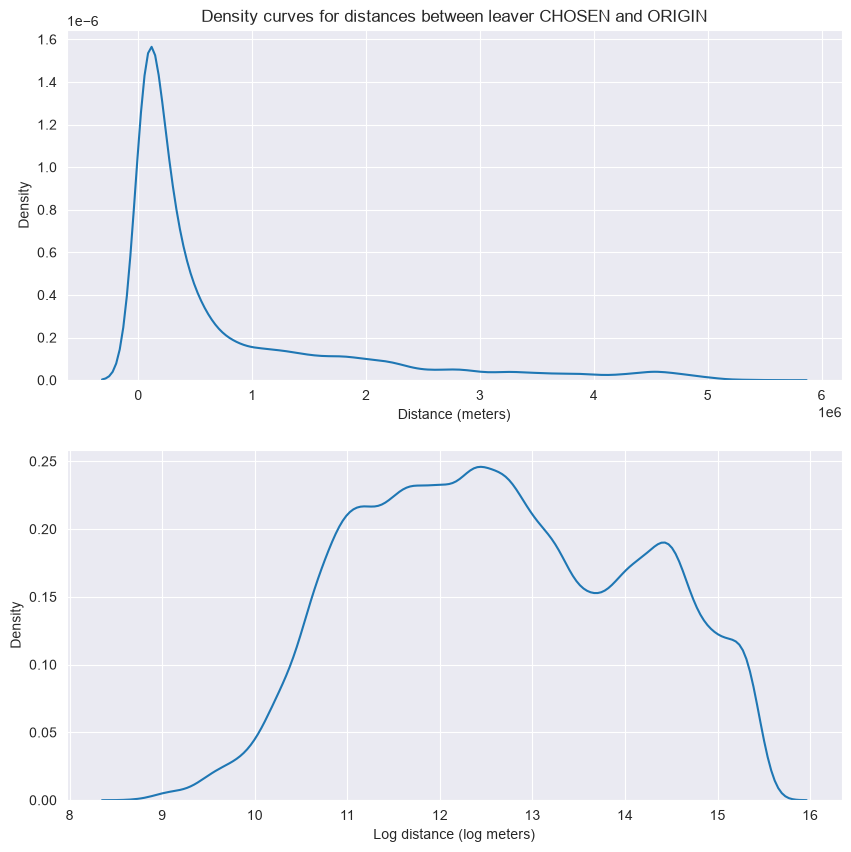

In [8]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
sns.kdeplot(leavers["dist"], ax=ax[0])
sns.kdeplot(leavers["logdist"], ax=ax[1])
ax[0].set_title("Density curves for distances between leaver CHOSEN and ORIGIN")
ax[0].set_xlabel("Distance (meters)")
ax[1].set_xlabel("Log distance (log meters)")

In [9]:
pums[pums["STAY"] == 0].groupby("CHOSEN")["PERWT"].sum().sort_values()

CHOSEN
1208609       60.0
0603743       88.0
1208607      235.0
2504301      253.0
4806701      266.0
            ...   
1702100    19742.0
0611300    21353.0
2503301    21728.0
5151154    22275.0
4500604    25846.0
Name: PERWT, Length: 2336, dtype: float64

In [10]:
pums[pums["STAY"] == 0].groupby("ORIGIN")["PERWT"].sum().sort_values()

ORIGIN
0502000       813.0
2300100       834.0
2100700      1054.0
2101000      1130.0
2200600      1312.0
             ...   
0800190    104450.0
4804600    107185.0
2500390    120781.0
1703400    122571.0
0603700    207425.0
Name: PERWT, Length: 975, dtype: float64

In [ ]:
x = pums[(pums["STAY"] == 0) & (pums["ORIGIN_STATE"] == pums["STATEFIP"])][
    "PERWT"
].sum()
y = pums[pums["STAY"] == 0]["PERWT"].sum()
print(x, y, x / y)

5665739.0 10316808.0 0.549175578337796


In [33]:
x = pums[(pums["STAY"] == 0) & (pums["BPL_REF"] == pums["STATEFIP"])]["PERWT"].sum()
y = pums[pums["STAY"] == 0]["PERWT"].sum()
print(x, y, x / y)

4330758.0 10316808.0 0.41977693100424085


In [28]:
pums_with_cbsa = pums.merge(
    puma_data[["NAME_NUM"]].add_suffix(".CHOSEN"),
    how="left",
    left_on="CHOSEN",
    right_index=True,
).merge(
    migpuma_data[["NAME_NUM"]].add_suffix(".ORIG"),
    how="left",
    left_on="ORIGIN",
    right_index=True,
)

In [ ]:
x = pums_with_cbsa[
    (pums_with_cbsa["STAY"] == 0)
    & (pums_with_cbsa["NAME_NUM.CHOSEN"] == pums_with_cbsa["NAME_NUM.ORIG"])
]["PERWT"].sum()
y = pums_with_cbsa[pums_with_cbsa["STAY"] == 0]["PERWT"].sum()
print(x, y, x / y)

2078328.0 10316808.0 0.20145068125722607


In [ ]:
puma_data[["NAME_NUM"]].add_suffix(".ORIG")

,NAME_NUMORIG
PUMA,
0100100,47
0100200,130
0100301,130
0100302,130
0100400,123
...,...
5600100,-1
5600200,311
5600300,312


In [25]:
migpuma_data["NAME_NUM"]

MIGPUMA
0100190     -2
0100290    130
0100400    123
0100600    499
0100700    498
          ... 
5600100     -2
5600200    311
5600300    312
5600400     -2
5600500     -2
Name: NAME_NUM, Length: 975, dtype: int64